<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [1]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *
from sklearn.utils import class_weight


from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [3]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [4]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [5]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [6]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

In [7]:
# 기존 훈련 데이터 불러오기
original_df = pd.read_csv(path + 'data.csv')
print(original_df.shape)

(19278, 23)


In [8]:
new_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         850 non-null    int64  
 1   ID                                 850 non-null    int64  
 2   Gender                             850 non-null    object 
 3   Customer Type                      850 non-null    object 
 4   Age                                817 non-null    float64
 5   Type of Travel                     850 non-null    object 
 6   Class                              850 non-null    object 
 7   Flight Distance                    850 non-null    int64  
 8   Inflight wifi service              830 non-null    float64
 9   Departure/Arrival time convenient  850 non-null    int64  
 10  Ease of Online booking             850 non-null    int64  
 11  Gate location                      850 non-null    int64  

In [9]:
new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         350 non-null    int64  
 1   ID                                 350 non-null    int64  
 2   Gender                             350 non-null    object 
 3   Customer Type                      350 non-null    object 
 4   Age                                340 non-null    float64
 5   Type of Travel                     350 non-null    object 
 6   Class                              350 non-null    object 
 7   Flight Distance                    350 non-null    int64  
 8   Inflight wifi service              335 non-null    float64
 9   Departure/Arrival time convenient  350 non-null    int64  
 10  Ease of Online booking             350 non-null    int64  
 11  Gate location                      350 non-null    int64  

In [10]:
new_test['Satisfaction'].value_counts()

,count
Satisfaction,
Neutral or Dissatisfied,191
Satisfied,159


In [11]:
new_train['Satisfaction'].value_counts()

,count
Satisfaction,
Neutral or Dissatisfied,463
Satisfied,387


In [12]:
new_train.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,850.000000,850.000000,817.000000,850.000000,830.000000,850.000000,850.000000,850.000000,836.000000,850.000000,823.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,847.000000
mean,52186.782353,68038.528235,38.887393,1243.060000,2.742169,3.044706,2.772941,3.015294,3.206938,3.260000,3.465371,3.360000,3.372941,3.330588,3.629412,3.295294,3.611765,3.274118,14.455294,14.981110
std,30002.047030,37653.069414,15.507890,1010.359805,1.328369,1.507852,1.380999,1.263234,1.339050,1.329887,1.325752,1.351107,1.299079,1.322143,1.204753,1.274411,1.193762,1.330591,37.173911,37.835117
min,271.000000,66.000000,7.000000,83.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,26769.500000,36066.500000,27.000000,436.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,51662.000000,68474.500000,40.000000,901.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,78419.000000,103302.500000,50.000000,1945.250000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,10.000000,11.000000
max,103687.000000,129690.000000,85.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,319.000000,317.000000


In [13]:
new_test.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,350.000000,350.000000,340.000000,350.000000,335.000000,350.000000,350.000000,350.000000,342.000000,350.000000,346.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,48425.068571,65152.657143,39.658824,1208.000000,2.650746,3.125714,2.711429,3.034286,3.251462,3.177143,3.473988,3.414286,3.434286,3.348571,3.634286,3.428571,3.614286,3.385714,15.157143,14.882857
std,29544.205709,37229.827120,15.664667,997.817797,1.360408,1.470306,1.414066,1.248023,1.309087,1.405084,1.319053,1.340282,1.332843,1.351508,1.183928,1.217958,1.217034,1.296821,36.684138,37.421099
min,605.000000,421.000000,7.000000,67.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,23269.000000,33102.250000,26.000000,431.750000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.250000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,46005.500000,63395.000000,40.500000,877.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.500000,0.000000,0.000000
75%,73979.750000,99287.750000,52.000000,1711.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,4.000000,11.000000,9.000000
max,103826.000000,129803.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,274.000000,310.000000


In [14]:
new_train.isnull().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,33
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,20
Departure/Arrival time convenient,0


In [15]:
new_test.isnull().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,10
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,15
Departure/Arrival time convenient,0


## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)

## **새로운 학습 전략:**

### **방법 1: 원본 데이터 + 새로운 학습/평가 데이터를 포함한 전체 데이터로 학습**
- `original_df` (raw), `new_train`, `new_test` 를 합쳐서 `x_combined_train`, `y_combined_train`을 생성합니다.
- `base_model`을 초기화하여 이 데이터로 다시 학습(`model1`).

### **방법 2: 새로운 학습 데이터(`new_train`)만으로 추가 학습**
- `new_train` 데이터만으로 `x_train_new_data`, `y_train_new_data`를 생성합니다.
- 기존 `base_model`에 `new_train` 데이터만으로 추가 학습(`model2`) 또는 미세 조정(`model3`).

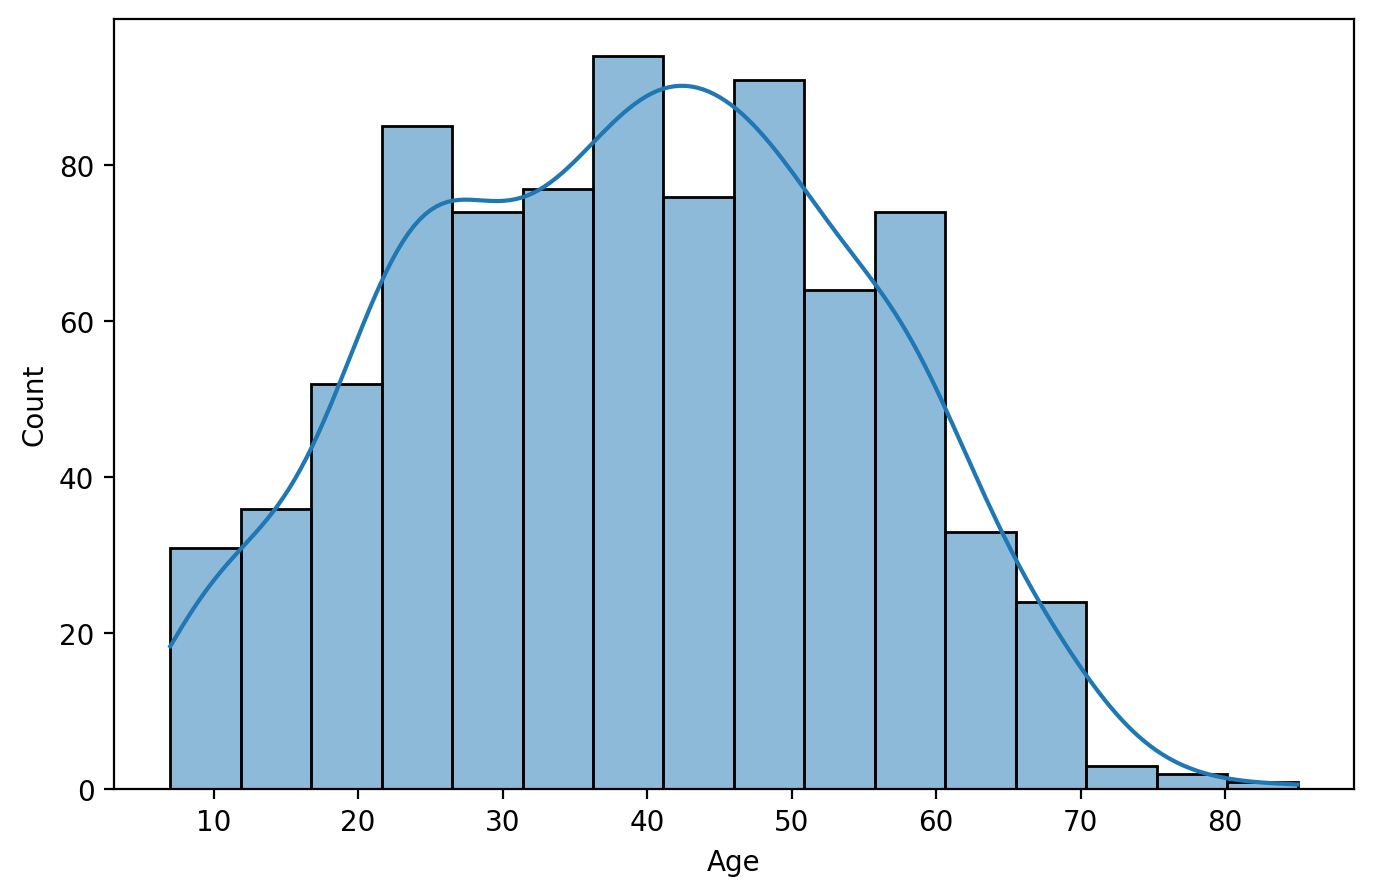

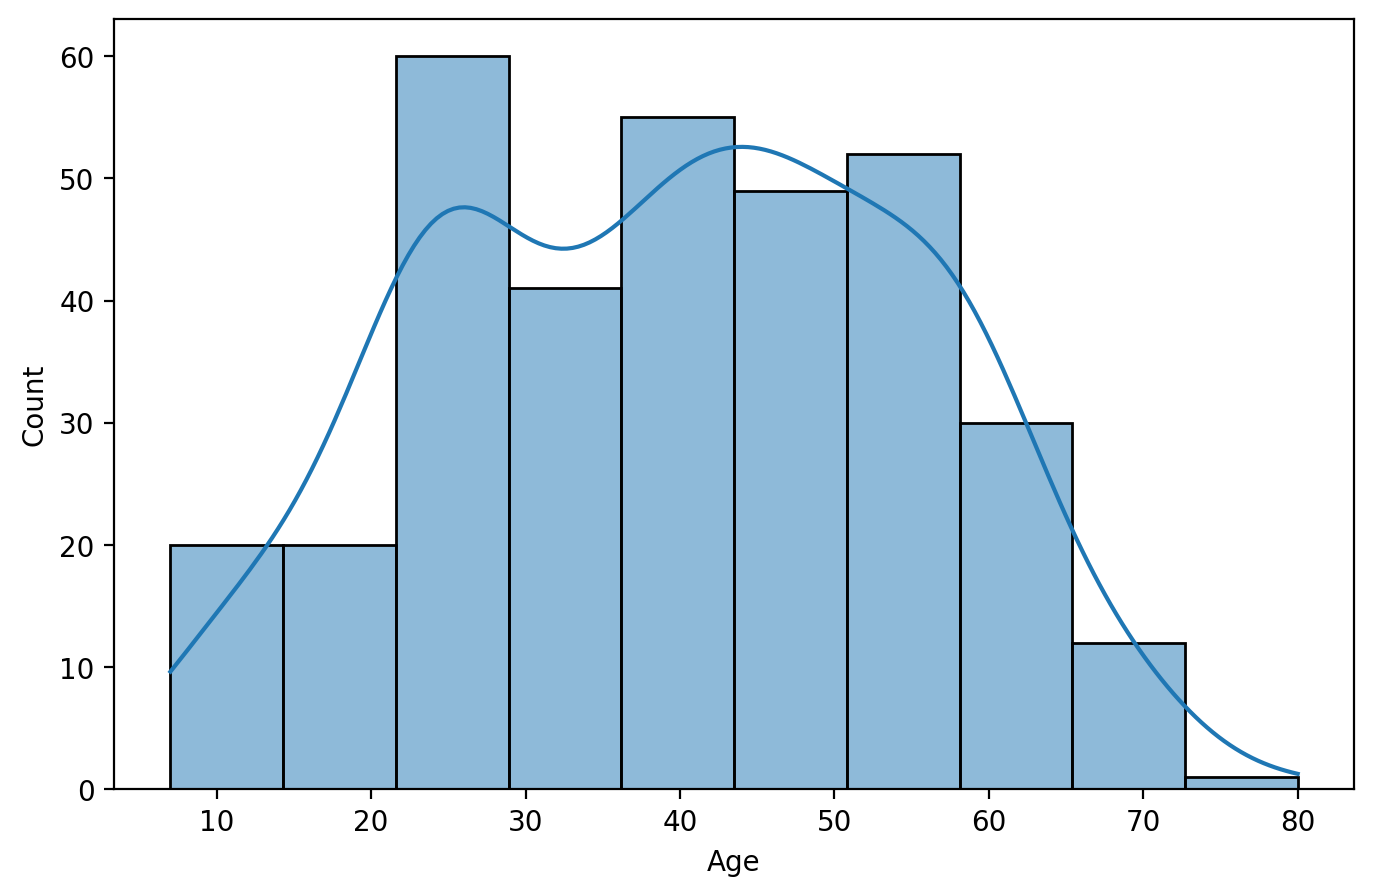

In [16]:
# 결측치 처리전 확인
# Age
plt.figure(figsize=(8, 5))
sns.histplot(new_train['Age'], kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(new_test['Age'], kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

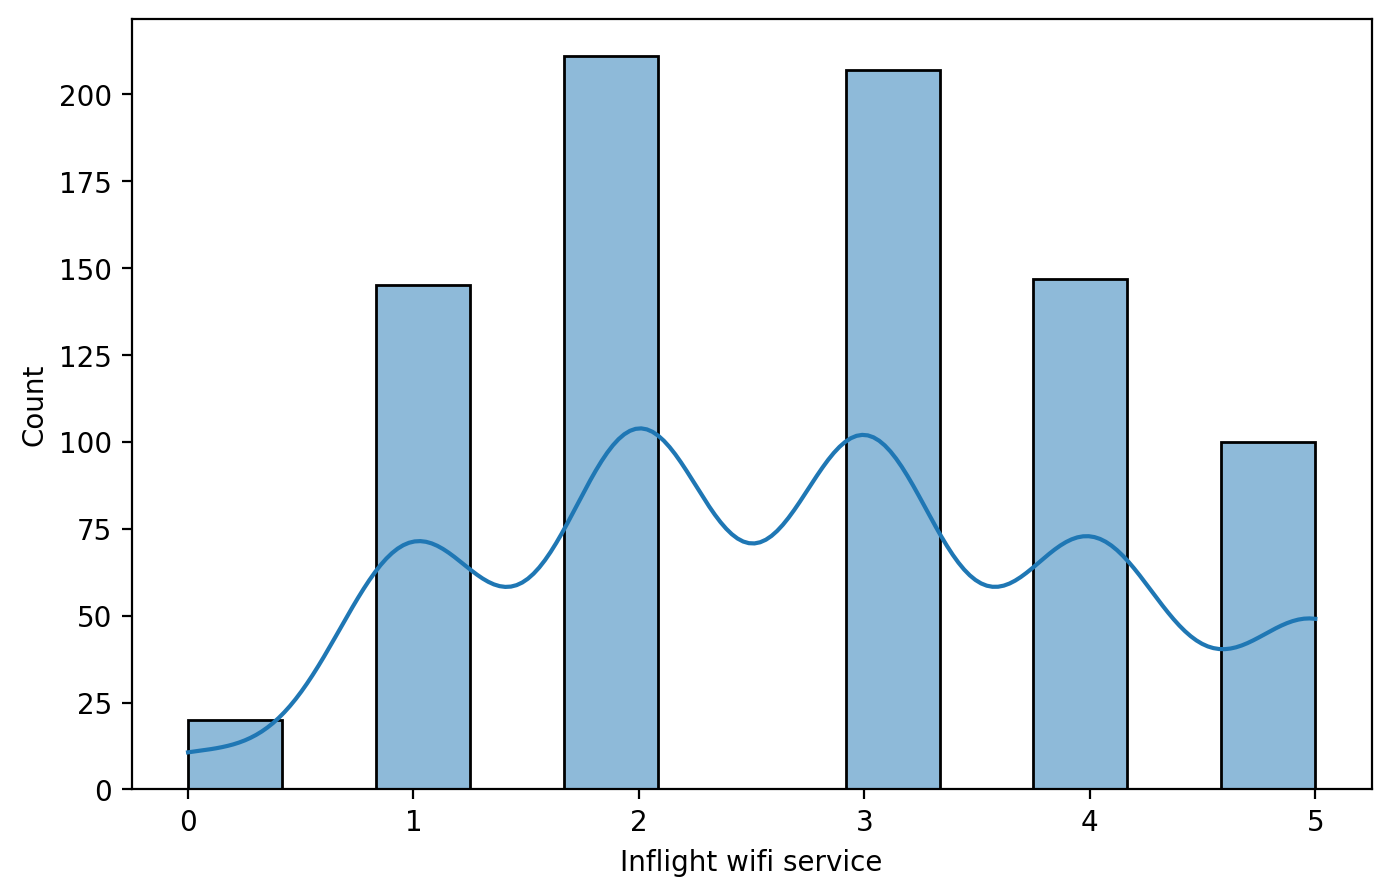

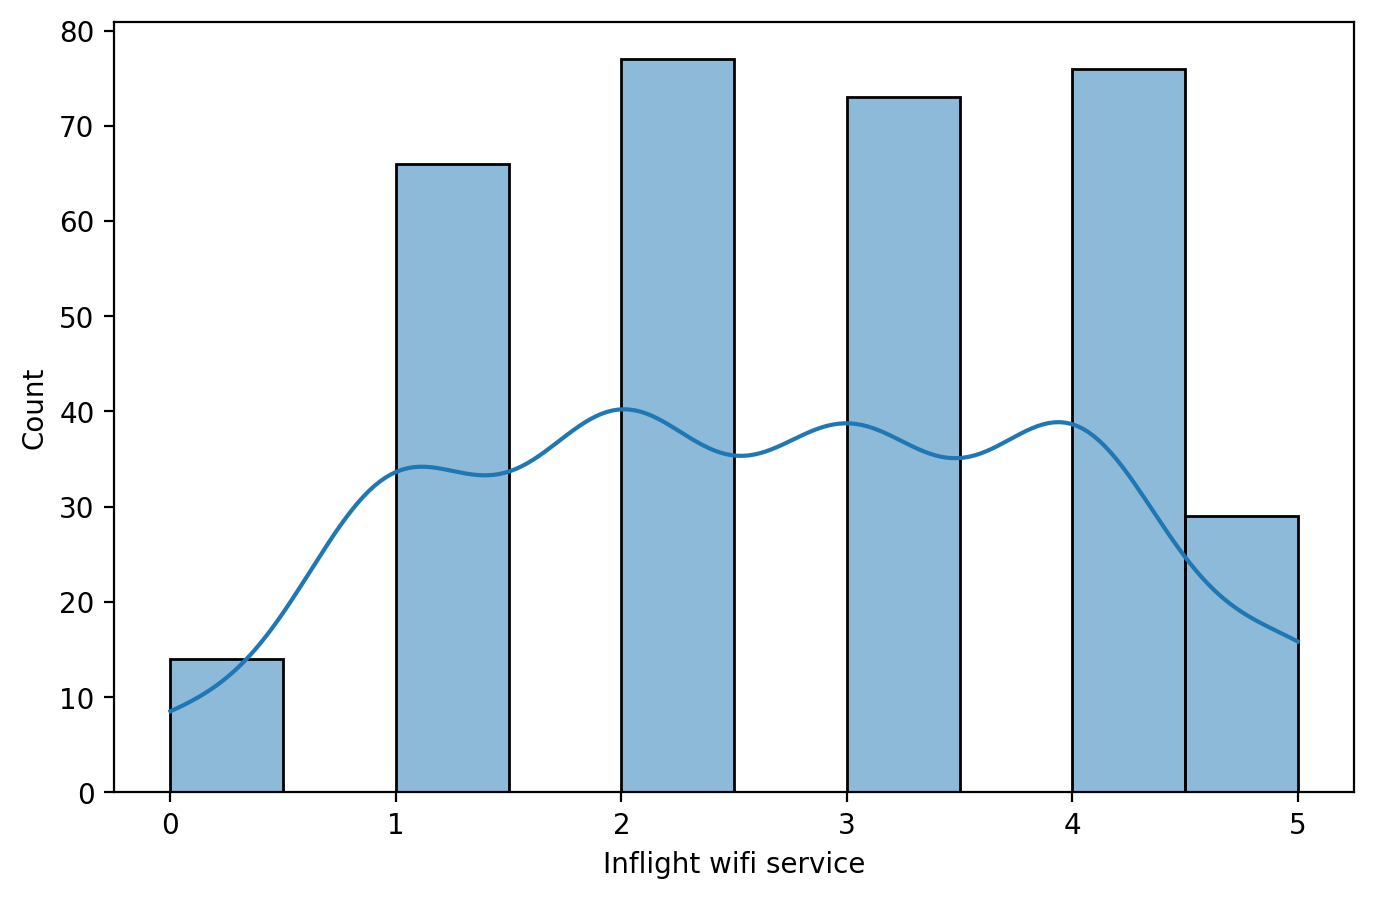

In [17]:
# 결측치 처리전 확인
# Inflight wifi service
plt.figure(figsize=(8, 5))
sns.histplot(new_train['Inflight wifi service'], kde=True)
plt.xlabel('Inflight wifi service')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(new_test['Inflight wifi service'], kde=True)
plt.xlabel('Inflight wifi service')
plt.ylabel('Count')
plt.show()

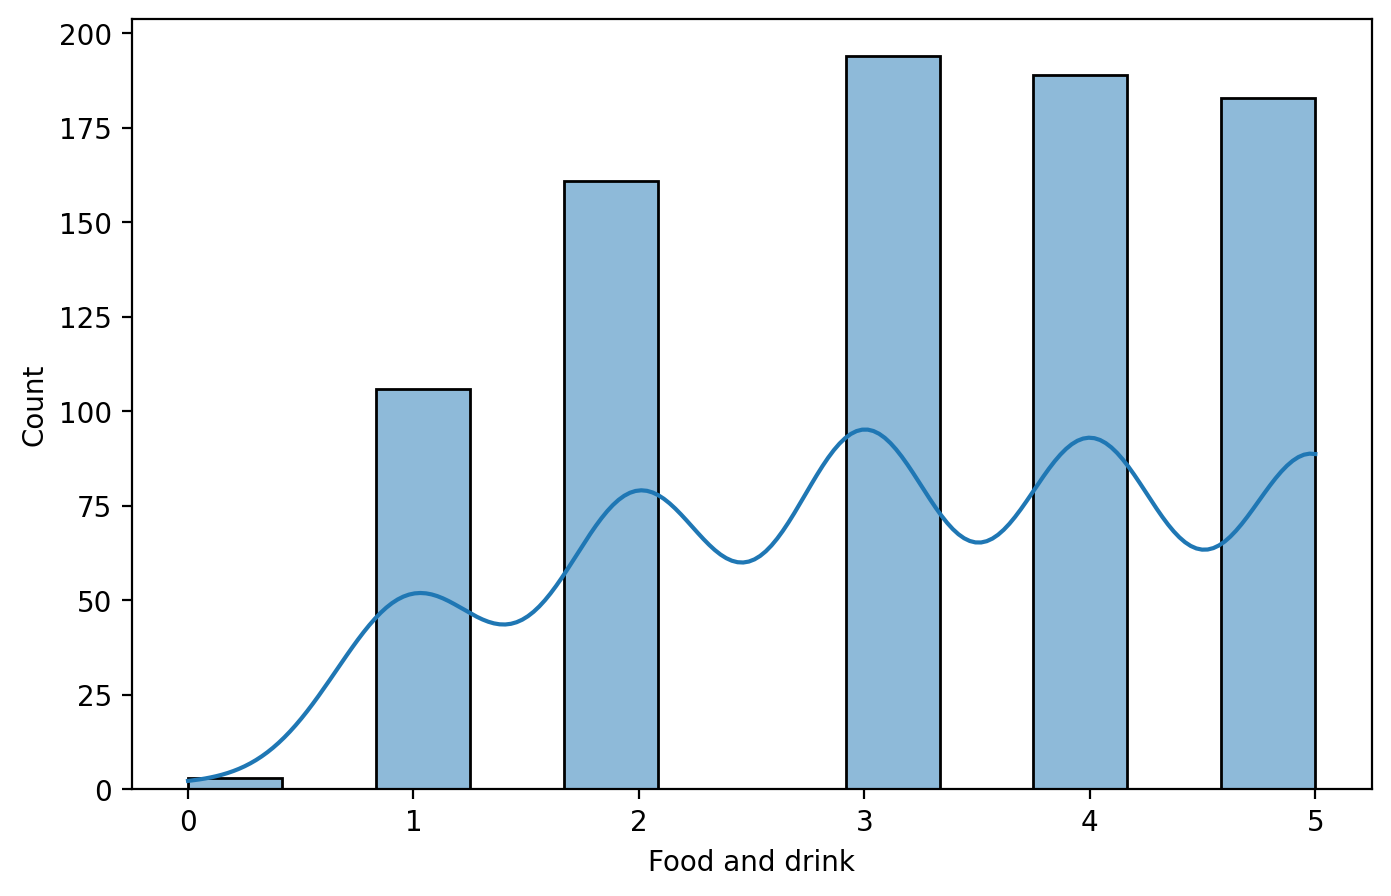

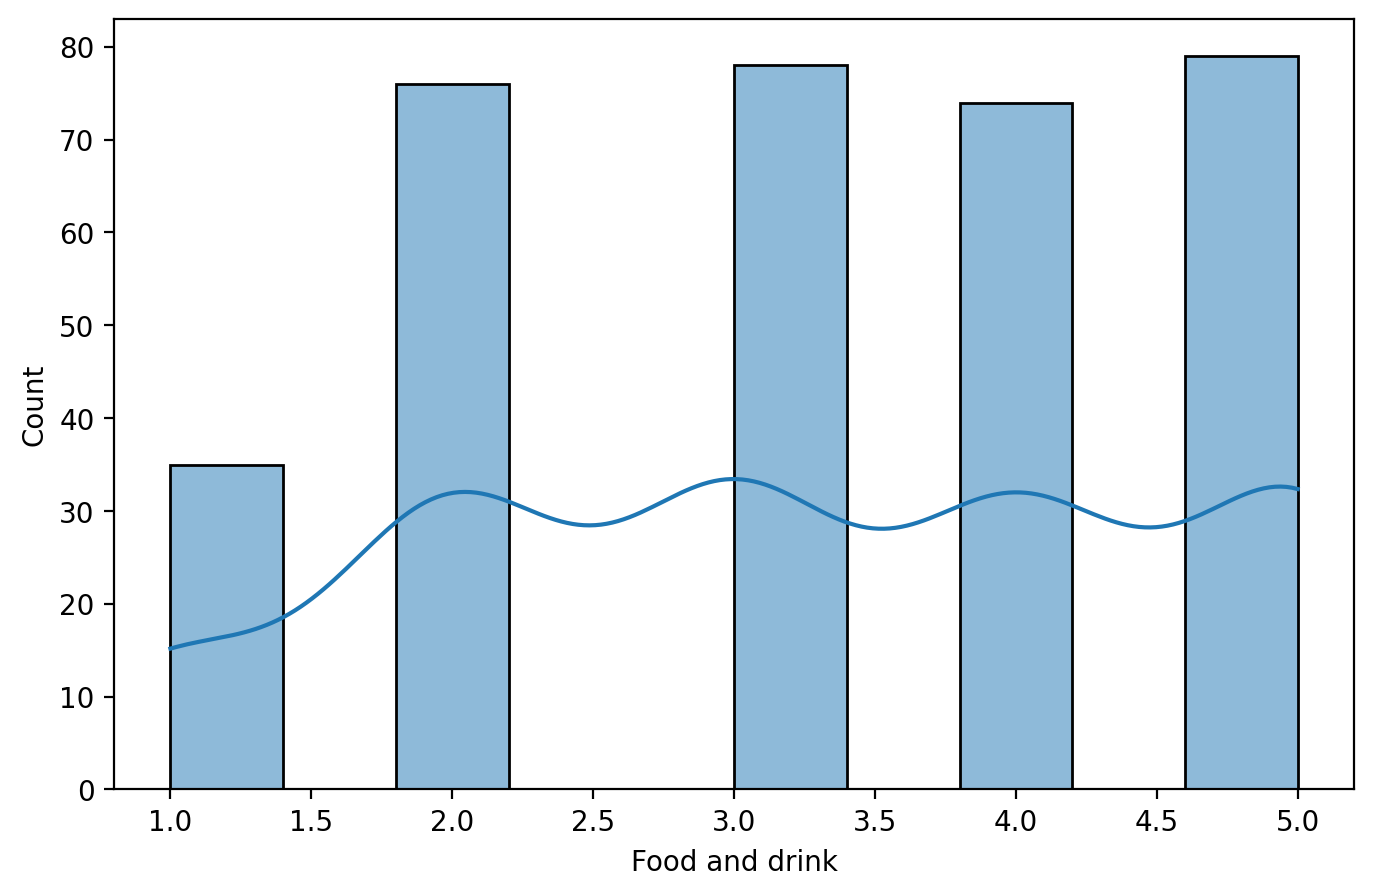

In [18]:
# 결측치 처리전 확인
# Food and drink
plt.figure(figsize=(8, 5))
sns.histplot(new_train['Food and drink'], kde=True)
plt.xlabel('Food and drink')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(new_test['Food and drink'], kde=True)
plt.xlabel('Food and drink')
plt.ylabel('Count')
plt.show()

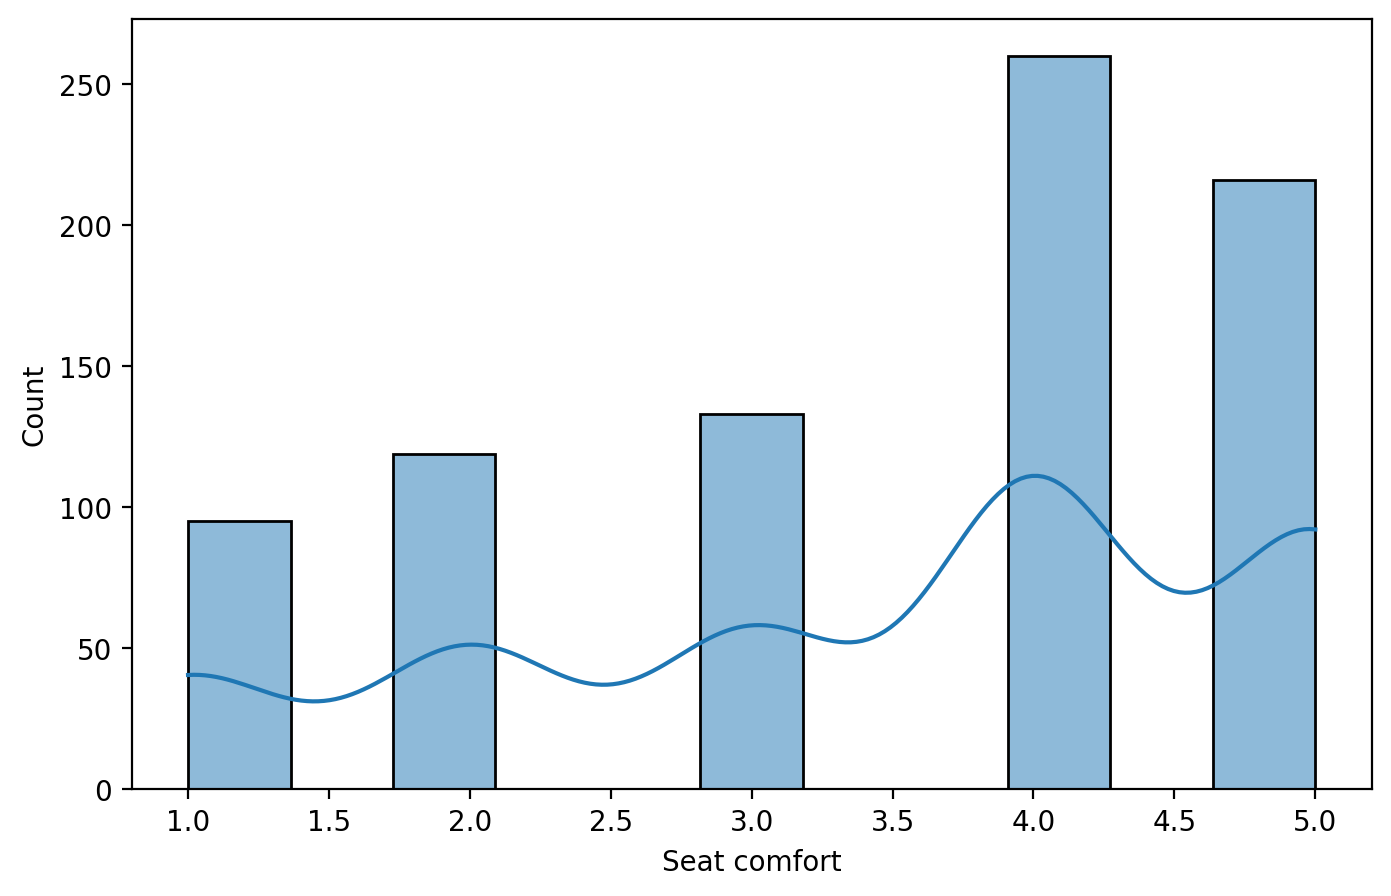

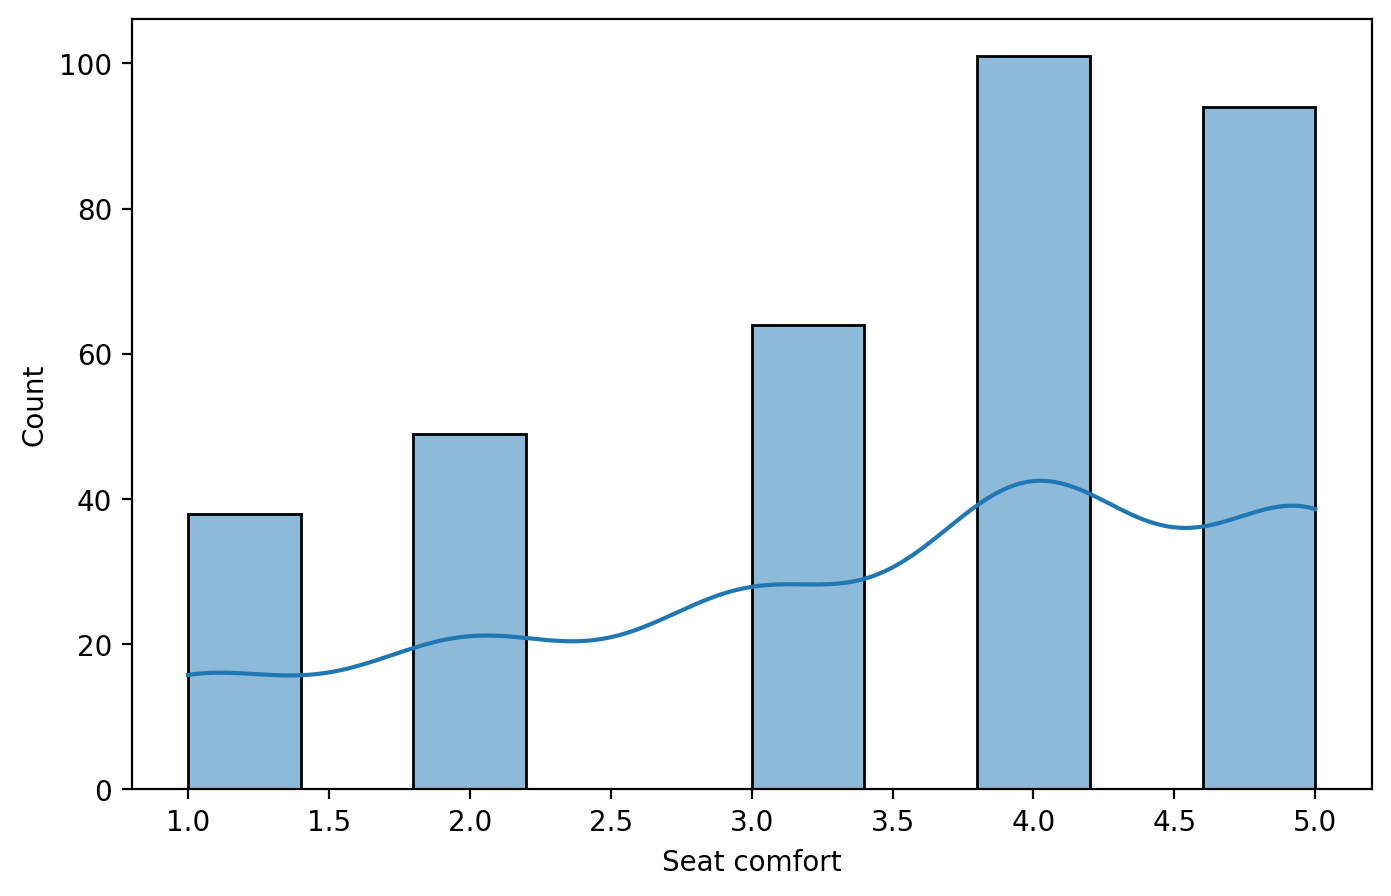

In [19]:
# 결측치 처리전 확인
# Seat comfort
plt.figure(figsize=(8, 5))
sns.histplot(new_train['Seat comfort'], kde=True)
plt.xlabel('Seat comfort')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(new_test['Seat comfort'], kde=True)
plt.xlabel('Seat comfort')
plt.ylabel('Count')
plt.show()

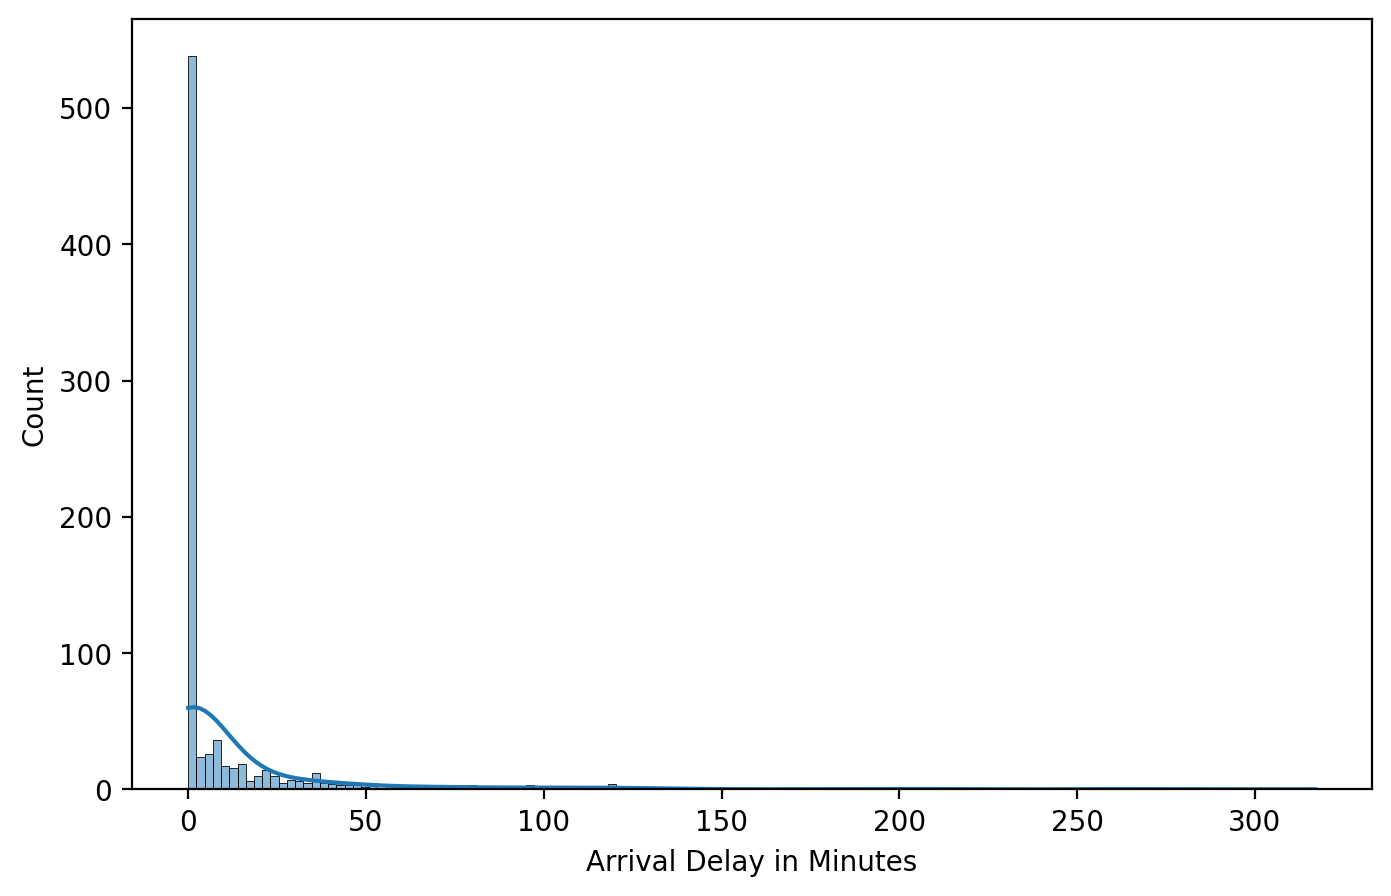

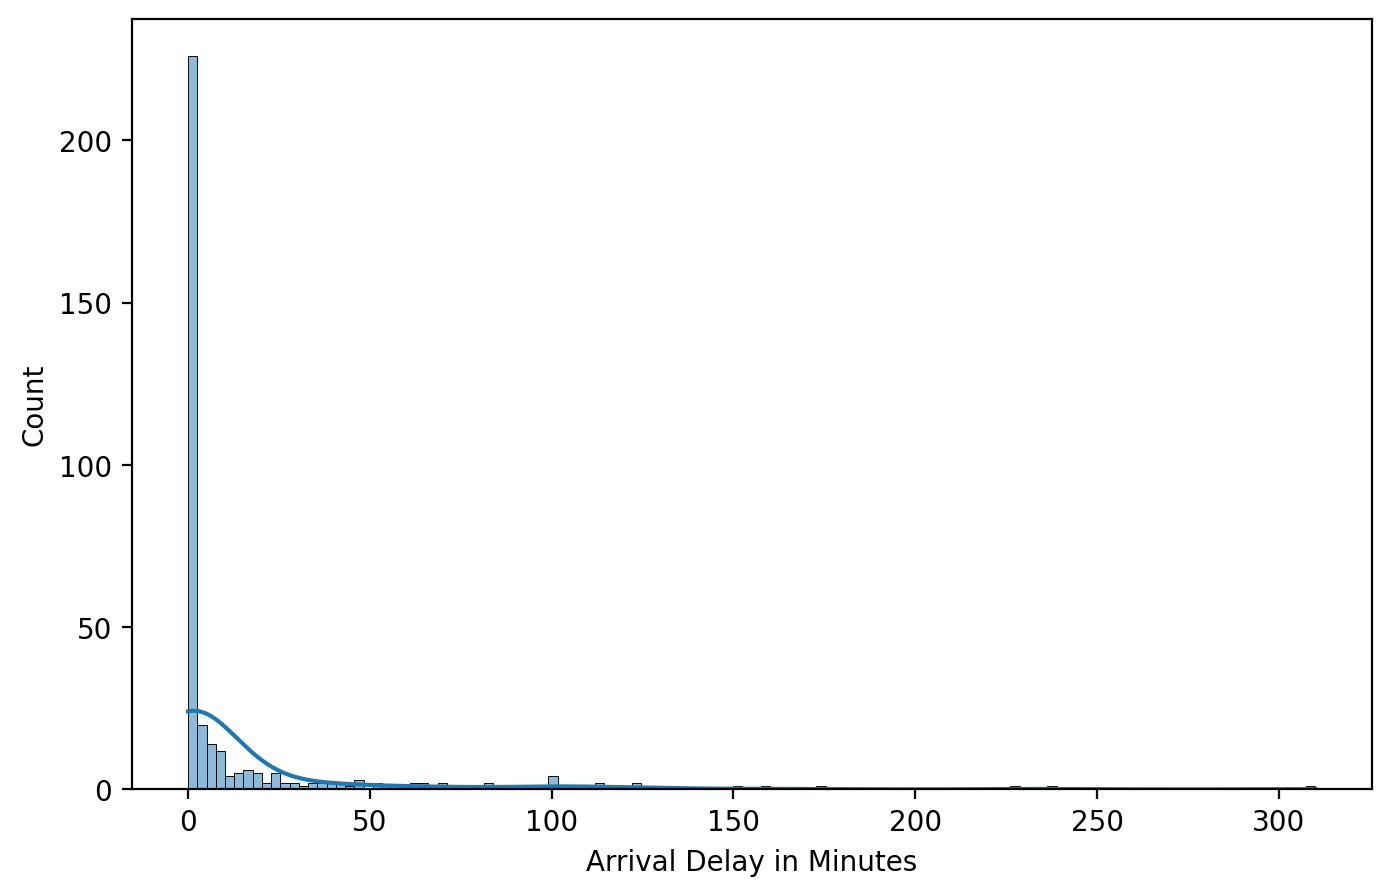

In [20]:
# 결측치 처리전 확인
# Arrival Delay in Minutes
plt.figure(figsize=(8, 5))
sns.histplot(new_train['Arrival Delay in Minutes'], kde=True)
plt.xlabel('Arrival Delay in Minutes')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(new_test['Arrival Delay in Minutes'], kde=True)
plt.xlabel('Arrival Delay in Minutes')
plt.ylabel('Count')
plt.show()

In [21]:
def build_model_input(data):
    df = data.copy()

    # 1. 결측치 처리 (수치형/점수형 변수)
    impute_cols = ['Age', 'Inflight wifi service', 'Food and drink', 'Seat comfort', 'Arrival Delay in Minutes']
    for col in impute_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # 2. Target 값 변경 및 결측치 행 제거
    y = None
    if 'Satisfaction' in df.columns:
        df['Satisfaction'] = df['Satisfaction'].str.lower()
        df['Satisfaction'] = df['Satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

        df = df.dropna(subset=['Satisfaction'])

        if df.empty:
            return pd.DataFrame(), np.array([])

        y = df['Satisfaction'].values
        df.drop(columns=['Satisfaction'], inplace=True)

    # 3. 불필요한 변수 제거
    df.drop(columns=['Unnamed: 0', 'ID'], inplace=True, errors='ignore')

    # 4. 라벨 인코딩
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
    if 'Customer Type' in df.columns:
        df['Customer Type'] = df['Customer Type'].str.lower().map({'loyal customer': 1, 'disloyal customer': 0})

    # 5. 가변수화
    cat_cols = ['Type of Travel', 'Class', 'Inflight wifi service', 'Departure/Arrival time convenient',
                'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding',
                'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service',
                'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
    existing_cat_cols = [c for c in cat_cols if c in df.columns]
    df = pd.get_dummies(df, columns=existing_cat_cols)

    # 6. 스케일러 피처와 일치시키기
    try:
        cols = scaler.feature_names_in_.tolist()
        for col in cols:
            if col not in df.columns:
                df[col] = 0
        x = df[cols]
    except AttributeError:
        x = df

    if x.empty:
        return pd.DataFrame(), np.array([])

    # 7. 스케일링 적용
    x_scaled = scaler.transform(x)
    x_final = pd.DataFrame(x_scaled, columns=x.columns)

    return x_final, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [22]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print('x_val shape:', x_val.shape)
print('y_val shape:', y_val.shape)

x_val shape: (350, 78)
y_val shape: (350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [23]:
# 방법 2를 위한 데이터 준비 (new_train만 사용)
x_train_new_data, y_train_new_data = build_model_input(new_train)

# 검증 데이터는 모든 모델에서 동일하게 사용
x_val, y_val = build_model_input(new_test)

print('x_train_new_data shape:', x_train_new_data.shape, 'y_train_new_data shape:', y_train_new_data.shape)
print('x_val shape:', x_val.shape, 'y_val shape:', y_val.shape)

x_train_new_data shape: (850, 78) y_train_new_data shape: (850,)
x_val shape: (350, 78) y_val shape: (350,)


### 전처리 후 결측치 및 데이터 타입 확인

In [117]:
# x_train 결측치 확인
print(x_train_new_data.isnull().sum().sum())

# x_val 결측치 확인
print(x_val.isnull().sum().sum())

0
0


In [118]:
x_train_new_data.info() # object 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 78 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Gender                               850 non-null    float64
 1   Customer Type                        850 non-null    float64
 2   Age                                  850 non-null    float64
 3   Type of Travel                       850 non-null    float64
 4   Class                                850 non-null    float64
 5   Flight Distance                      850 non-null    float64
 6   Departure Delay in Minutes           850 non-null    float64
 7   Arrival Delay in Minutes             850 non-null    float64
 8   Inflight wifi service_1              850 non-null    float64
 9   Inflight wifi service_2              850 non-null    float64
 10  Inflight wifi service_3              850 non-null    float64
 11  Inflight wifi service_4         

In [119]:
x_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 78 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Gender                               350 non-null    float64
 1   Customer Type                        350 non-null    float64
 2   Age                                  350 non-null    float64
 3   Type of Travel                       350 non-null    float64
 4   Class                                350 non-null    float64
 5   Flight Distance                      350 non-null    float64
 6   Departure Delay in Minutes           350 non-null    float64
 7   Arrival Delay in Minutes             350 non-null    float64
 8   Inflight wifi service_1              350 non-null    float64
 9   Inflight wifi service_2              350 non-null    float64
 10  Inflight wifi service_3              350 non-null    float64
 11  Inflight wifi service_4         

### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- **방법 1:** `original_df`, `new_train`, `new_test`를 합쳐 `x_combined_train`, `y_combined_train`을 준비합니다.
- **방법 2:** `new_train` 데이터프레임을 `x_train_new_data`, `y_train_new_data`로 분리합니다. (위에서 이미 수행됨)

In [25]:
# 방법 1: original_df, new_train, new_test를 합친 데이터 준비
# 주의: original_df는 build_model_input 함수가 예상하는 '원시' 상태여야 합니다.
# 기존 original_df가 이미 전처리된 상태일 수 있으므로, 다시 로드하여 raw 상태로 사용합니다.
df_raw_original = pd.read_csv(path + 'data.csv')

# ID 컬럼을 제외한 모든 컬럼에 대해 결합 (Unnamed: 0은 build_model_input에서 처리됨)
# new_train과 new_test는 이미 로드된 상태이므로 그대로 사용
combined_raw_df = pd.concat([df_raw_original, new_train, new_test], ignore_index=True)

x_combined_train, y_combined_train = build_model_input(combined_raw_df)

# Combined data에 대한 클래스 가중치 계산
class_weights_combined = class_weight.compute_class_weight('balanced', classes=np.unique(y_combined_train), y=y_combined_train)
class_weight_dict_combined = dict(enumerate(class_weights_combined))

print('x_combined_train shape:', x_combined_train.shape)
print('y_combined_train shape:', y_combined_train.shape)
print('Class Weight Dictionary (Combined Data):', class_weight_dict_combined)

# 방법 2: new_train 데이터에 대한 클래스 가중치 계산 (model2, model3용)
class_weights_new_data = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_new_data), y=y_train_new_data)
class_weight_dict_new_data = dict(enumerate(class_weights_new_data))

print('\nx_train_new_data shape:', x_train_new_data.shape)
print('y_train_new_data shape:', y_train_new_data.shape)
print('Class Weight Dictionary (New Data Only):', class_weight_dict_new_data)

x_combined_train shape: (1200, 78)
y_combined_train shape: (1200,)
Class Weight Dictionary (Combined Data): {0: np.float64(0.9174311926605505), 1: np.float64(1.098901098901099)}

x_train_new_data shape: (850, 78)
y_train_new_data shape: (850,)
Class Weight Dictionary (New Data Only): {0: np.float64(0.91792656587473), 1: np.float64(1.0981912144702843)}


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.5042 - loss: 0.7809 - val_accuracy: 0.5571 - val_loss: 0.7709
Epoch 2/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4950 - loss: 0.7741 - val_accuracy: 0.5571 - val_loss: 0.7692
Epoch 3/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4875 - loss: 0.7797 - val_accuracy: 0.5600 - val_loss: 0.7677
Epoch 4/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5067 - loss: 0.7762 - val_accuracy: 0.5571 - val_loss: 0.7663
Epoch 5/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4850 - loss: 0.7750 - val_accuracy: 0.5629 - val_loss: 0.7651
Epoch 6/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4983 - loss: 0.7705 - val_accuracy: 0.5714 - val_loss: 0.7641
Epoch 7/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5025 - loss: 0.7688 - val_accuracy: 0.5857 - val_loss: 0.7632
Epoch 8/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5067 - loss: 0.7652 - val_accuracy: 0.5943 -

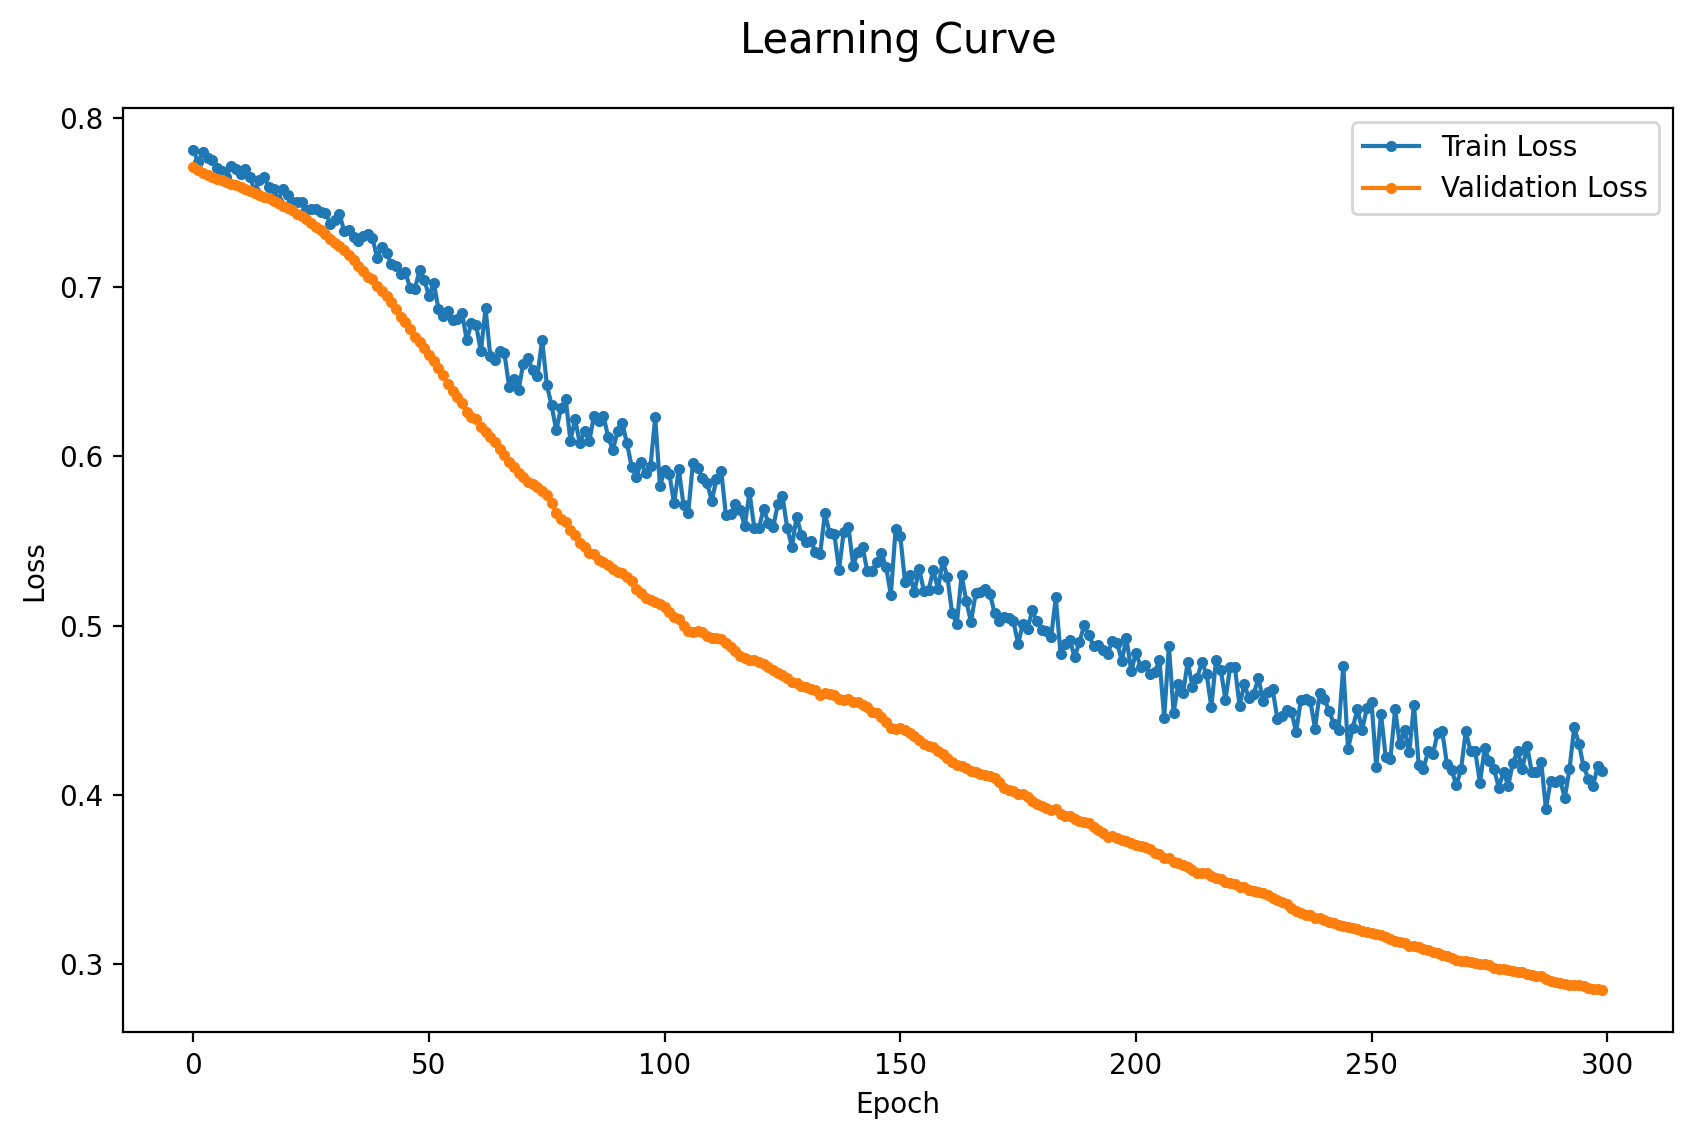

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       191
           1       0.91      0.92      0.92       159

    accuracy                           0.92       350
   macro avg       0.92      0.92      0.92       350
weighted avg       0.92      0.92      0.92       350



In [26]:
# 방법 1: 모델 초기화 및 전체 데이터로 학습
clear_session()
nf = x_combined_train.shape[1] # 전체 데이터셋의 피처 수

model1 = Sequential([
    Input(shape=(nf, )),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(4, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model1.summary()

# 학습 방법을 설정하고 학습을 수행합니다.
model1.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history1 = model1.fit(x_combined_train, y_combined_train, epochs=300, batch_size=32, validation_data=(x_val, y_val), callbacks=[es], verbose=1, class_weight=class_weight_dict_combined)

# 학습 곡선 확인
dl_history_plot(history1.history)

# 검증 데이터 평가
y_pred1 = model1.predict(x_val)
y_pred1 = (y_pred1 > 0.5).astype(int)

print(classification_report(y_val, y_pred1))

### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [27]:
# 방법 2: 기본 모델에 추가 학습
model2 = load_model(path + 'base_model.keras')
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,445 (240.02 KB)

 Trainable params: 20,481 (80.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,964 (160.02 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [28]:
# 방법 2: 기본 모델 불러와 이어 학습 (Continued Training) - new_train 데이터만 사용

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(x_train_new_data, y_train_new_data, epochs=300, batch_size=32, validation_data=(x_val, y_val), callbacks=[es], verbose=1, class_weight=class_weight_dict_new_data)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.5635 - loss: 3.2027 - val_accuracy: 0.5543 - val_loss: 3.2814
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6247 - loss: 2.2763 - val_accuracy: 0.5914 - val_loss: 2.5734
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6647 - loss: 1.7832 - val_accuracy: 0.6400 - val_loss: 2.0403
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7024 - loss: 1.4415 - val_accuracy: 0.6800 - val_loss: 1.6482
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7365 - loss: 1.1702 - val_accuracy: 0.7057 - val_loss: 1.3686
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7424 - loss: 1.0171 - val_accuracy: 0.7171 - val_loss: 1.1617
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7612 - loss: 0.8301 - val_accuracy: 0.7143 - val_loss: 0.9949
Epoch 8/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7812 - loss: 0.7618 - val_accuracy: 0.7400 -

- 학습 곡선을 확인합니다.

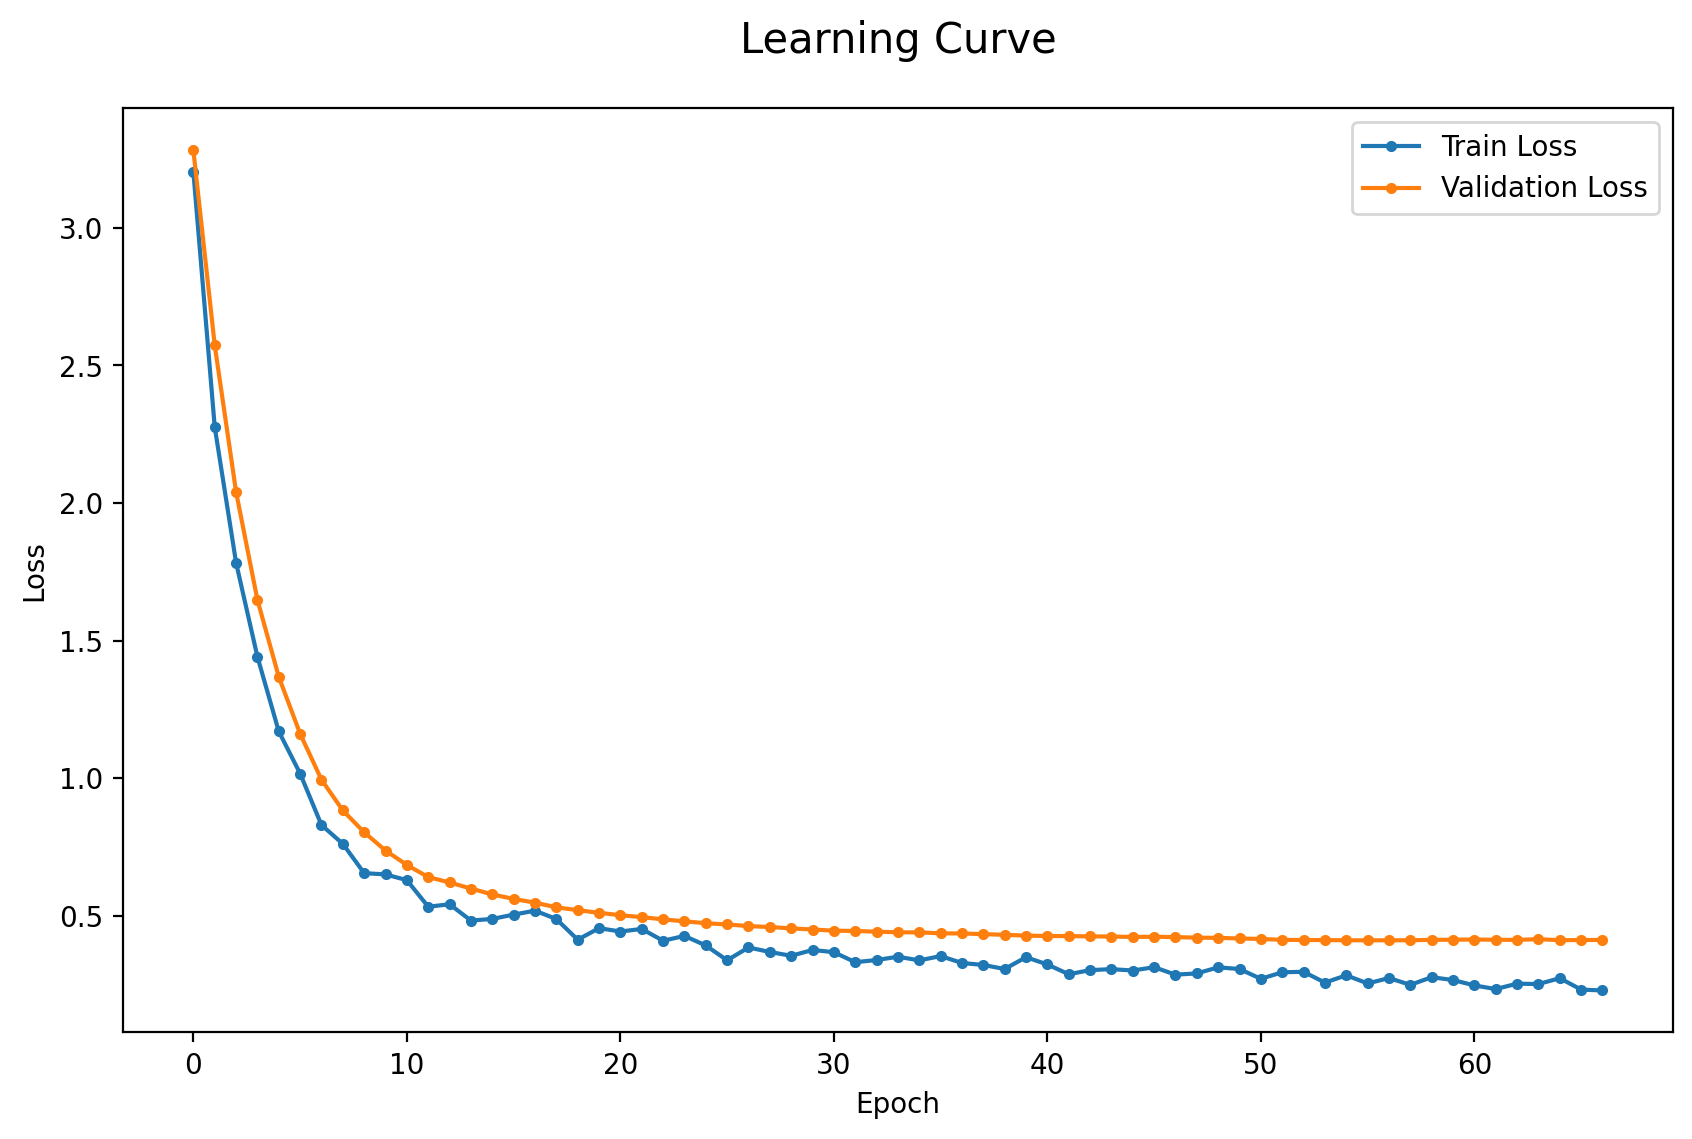

In [29]:
# 학습 곡선 확인
dl_history_plot(history2.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [30]:
# 검증 데이터 평가
y_pred2 = model2.predict(x_val)
y_pred2 = (y_pred2 > 0.5).astype(int)

print(classification_report(y_val, y_pred2))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       191
           1       0.80      0.84      0.82       159

    accuracy                           0.83       350
   macro avg       0.83      0.83      0.83       350
weighted avg       0.83      0.83      0.83       350



### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [83]:
# 방법 3: Fine-tuning
clear_session()

# 기본 모델 불러오기
base_model_ft = load_model(path + 'base_model.keras')

# 원본 모델의 출력층 제거
base_model_ft.pop()

# 기본 모델의 모든 레이어를 동결 (feature extractor로 사용)
for layer in base_model_ft.layers:
    layer.trainable = False

# 새로운 출력층을 추가하여 Fine-tuning 모델 구성
model3 = Sequential([
    base_model_ft,
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # 새로운 은닉층 추가
    Dropout(0.3),
    Dense(1, activation='sigmoid') # 새로운 출력층
])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32)             │        20,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,721 (80.94 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 20,448 (79.88 KB)

In [111]:
# 방법 3: Fine-tuning
clear_session()

# 이전 단계에서 선택된 더 좋은 모델 불러오기
base_model_ft = model1

# 원본 모델의 출력층 제거 (새로운 출력층을 추가하기 위함)
# 모델에 따라 출력층이 여러 개일 수 있으므로, 마지막 출력층을 가정합니다.
# 만약 모델 구조가 복잡하여 pop()으로 출력층 제거가 어렵다면, 새로운 Sequential 모델을 구성해야 합니다.
if base_model_ft.layers:
    base_model_ft.pop()

# 기본 모델의 모든 레이어를 동결 (feature extractor로 사용)
#for layer in base_model_ft.layers:
#    layer.trainable = False

for layer in base_model.layers[:-5]:
    layer.trainable = False

# 새로운 출력층을 추가하여 Fine-tuning 모델 구성
model3 = Sequential([
    base_model_ft,
    #Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # 새로운 은닉층 추가
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # 새로운 출력층
])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32)             │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 2,528 (9.88 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [112]:
# 학습 설정 및 수행 - new_train 데이터만 사용
model3.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history3 = model3.fit(x_train_new_data, y_train_new_data, epochs=200, batch_size=32, validation_data=(x_val, y_val), callbacks=[es], verbose=1, class_weight=class_weight_dict_new_data)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.4000 - loss: 0.7311 - val_accuracy: 0.4429 - val_loss: 0.7064
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5482 - loss: 0.6888 - val_accuracy: 0.7543 - val_loss: 0.6644
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7247 - loss: 0.6424 - val_accuracy: 0.8771 - val_loss: 0.6183
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8106 - loss: 0.5907 - val_accuracy: 0.9000 - val_loss: 0.5662
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8365 - loss: 0.5406 - val_accuracy: 0.9057 - val_loss: 0.5120
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8553 - loss: 0.4954 - val_accuracy: 0.9057 - val_loss: 0.4595
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8882 - loss: 0.4360 - val_accuracy: 0.9171 - val_loss: 0.4133
Epoch 8/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8941 - loss: 0.3990 - val_accuracy: 0.9229 - 

- 학습 곡선을 확인합니다.

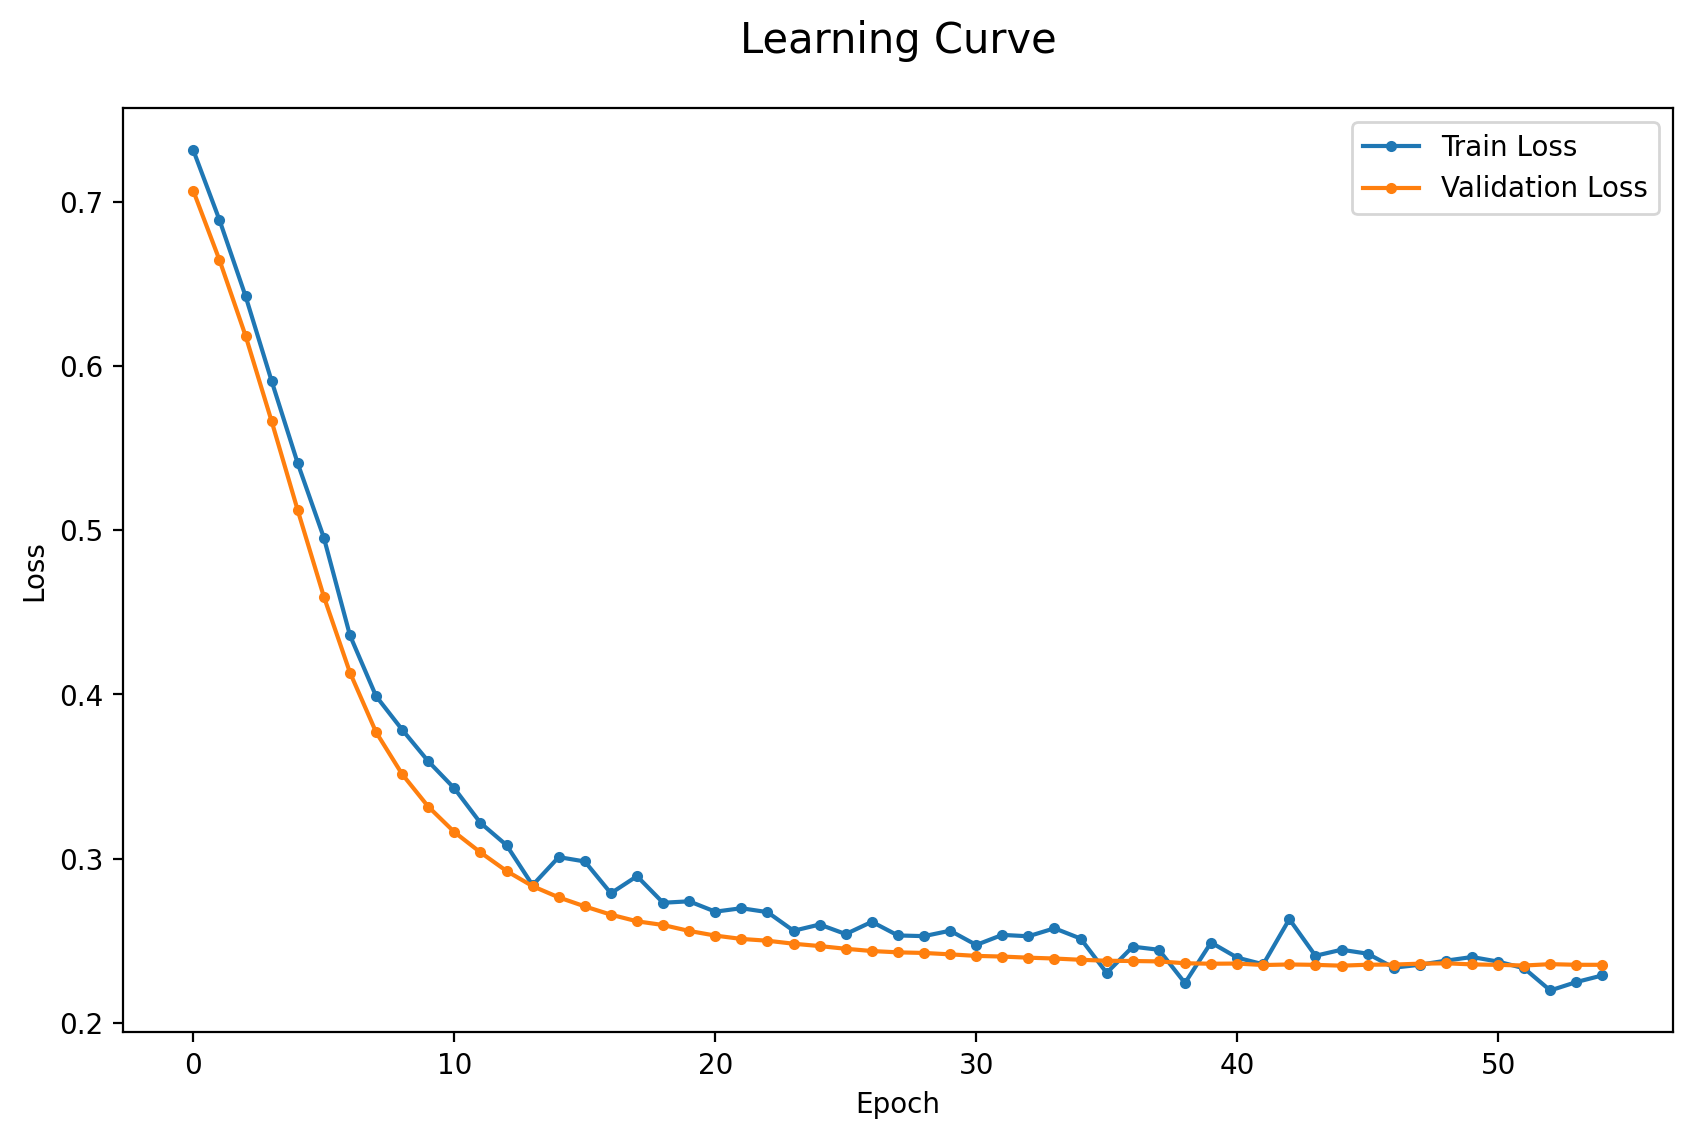

In [113]:
# 학습 곡선 확인
dl_history_plot(history3.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [116]:
# 검증 데이터 평가
y_pred3 = model3.predict(x_val)
y_pred3_class = (y_pred3 > 0.63).astype(int)


print(classification_report(y_val, y_pred3_class))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       191
           1       0.93      0.91      0.92       159

    accuracy                           0.93       350
   macro avg       0.93      0.92      0.92       350
weighted avg       0.93      0.93      0.93       350



In [115]:
# 임계값 그리드 서치
from sklearn.metrics import recall_score

MIN_RECALL = 0.9 # 원하는 최소 recall

candidates = [(t, recall_score(y_val, (y_pred3 > t).astype(int)))
              for t in np.arange(0.1, 0.91, 0.01)]

# recall >= 기준을 만족하는 것 중 threshold가 가장 높은 것 (= precision 최대)
valid = [(t, r) for t, r in candidates if r >= MIN_RECALL]
best_threshold = max(valid, key=lambda x: x[0])[0]
print(f"최적 임계값: {best_threshold:.2f}")

최적 임계값: 0.63
